# 金融資料探勘期末報告：MLPClassifier 預測 Target1

本 notebook 使用嚴格時間序列切分，利用指定特徵預測 `Target1`，並針對 threshold `0.40` 到 `0.50` 掃描 Precision、Recall 與 F1-score。共用函式已拆到 `utils.py`。

In [1]:
# 匯入必要套件
from pathlib import Path
import warnings

import pandas as pd
from IPython.display import display

from utils import (
    build_feature_stats,
    build_target_stats,
    get_network_architecture_info,
    get_dataset_info,
    load_sheet_data,
    plot_threshold_metrics,
    prepare_model_data,
    run_repeated_experiments,
    scale_without_leakage,
    time_series_train_test_split,
    export_summary_workbook,
)

# MLP 在小樣本與不同 seed 下可能出現收斂警告；本研究已設定 max_iter 與 early_stopping。
warnings.filterwarnings("ignore", category=UserWarning)

# 讓 pandas 顯示較完整，方便在 notebook 中檢查結果。
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [4]:
# ===== 參數設定 =====

# notebook 所在資料夾。
BASE_DIR = Path.cwd()

# 題目指定資料來源：第 2 個工作表。
EXCEL_PATH = BASE_DIR / "Index_411336001_2023.xlsx"

# 工作表參數：pandas 從 0 開始算，所以 1=第 2 個工作表，3=第 4 個工作表。
# 若要改讀第 4 個工作表，請改成 SHEET_NAME = 3。
SHEET_NAME = 3

# 輸出檔案。
OUTPUT_EXCEL_PATH = BASE_DIR / "ThresholdSummary.xlsx"
OUTPUT_CHART_PATH = BASE_DIR / "ThresholdMetrics.png"

# 題目指定 threshold 掃描範圍：0.40 到 0.50，每次增加 0.01。
THRESHOLDS = [round(value / 100, 2) for value in range(40, 51)]

# 題目指定 seed：1 到 30，共 30 次實驗。
SEEDS = range(32, 62)

神經網路架構參數：
輸入層神經元數：26 個，也就是 26 個金融特徵
隱藏層神經元數：(32, 16)
輸出層類別數：2 類，也就是 Target1=0 / Target1=1
Activation：relu，Solver：adam



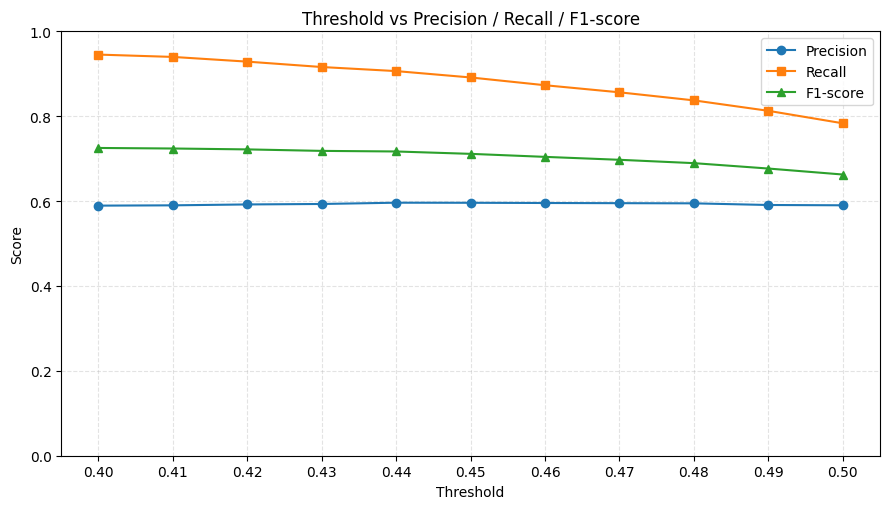

完成模型實驗與輸出。
有效資料筆數：367
訓練集筆數：293，測試集筆數：74
測試集 Target1=1 筆數：42
輸出 Excel：d:\Github\Personal-Project\ndhu\金融數據探勘\期末救援\ThresholdSummary.xlsx
輸出圖檔：d:\Github\Personal-Project\ndhu\金融數據探勘\期末救援\ThresholdMetrics.png
Target1 次數統計表：


,Dataset,Target1,Count,Ratio
0,All,0,167,0.4550
1,All,1,200,0.5450
2,Train,0,135,0.4608
3,Train,1,158,0.5392
4,Test,0,32,0.4324
5,Test,1,42,0.5676


特徵敘述統計表：


,Feature,count,mean,std,min,25%,50%,75%,max
0,3M_Mu,367.0,0.185076,0.363920,-1.075935,-0.011404,0.180522,0.363412,1.243643
1,6M_Mu,367.0,0.172653,0.311221,-0.585487,-0.116316,0.216474,0.362810,0.834423
2,3M_Sigma,367.0,0.207960,0.061643,0.119788,0.141795,0.209396,0.245867,0.324314
3,6M_Sigma,367.0,0.205260,0.050657,0.131561,0.139103,0.228748,0.252586,0.271685
4,3M_Downsiderisk,367.0,0.092867,0.065139,0.000000,0.016070,0.100757,0.151940,0.190653
5,6M_Downsiderisk,367.0,0.091594,0.065199,0.000000,0.011731,0.098927,0.161936,0.171795
6,IV_C0,367.0,0.102783,0.068370,0.008423,0.054453,0.084839,0.130187,0.397359
7,IV_C1,367.0,0.102762,0.068411,0.008423,0.054453,0.084839,0.130187,0.397359
8,IV_C2,367.0,0.103068,0.068402,0.008423,0.054953,0.085615,0.131478,0.397359
9,IV_C3,367.0,0.103667,0.068269,0.008423,0.055616,0.086003,0.133626,0.397359


0.40 ~ 0.50 門檻值比較總表：


,Threshold,Avg_Pred1,Avg_TP,Precision,Recall,F1
0,0.40,67.4333,39.7000,0.5893,0.9452,0.7252
1,0.41,66.9667,39.4667,0.5900,0.9397,0.7239
2,0.42,65.9667,39.0000,0.5921,0.9286,0.7218
3,0.43,64.9333,38.4667,0.5932,0.9159,0.7183
4,0.44,64.0000,38.0667,0.5962,0.9063,0.7169
5,0.45,62.9667,37.4333,0.5960,0.8913,0.7113
6,0.46,61.6667,36.6667,0.5955,0.8730,0.7042
7,0.47,60.5000,35.9667,0.5951,0.8563,0.6973
8,0.48,59.1667,35.1667,0.5947,0.8373,0.6894
9,0.49,57.6333,34.1333,0.5908,0.8127,0.6767


In [5]:
# ===== 主流程：由上到下執行此 cell 即可產出報告需要的 Excel 與圖表 =====

# 讀取指定工作表，並整理模型需要的 X 與 y。
raw_df = load_sheet_data(EXCEL_PATH, sheet_name=SHEET_NAME)
X, y = prepare_model_data(raw_df)

# 顯示神經網路架構。
# MLPClassifier 的輸入層由特徵數自動決定，輸出層由 Target1 的類別數自動決定；隱藏層由 utils.py 的 HIDDEN_LAYER_SIZES 指定。
architecture_info = get_network_architecture_info(X, y)
print("神經網路架構參數：")
print(f"輸入層神經元數：{architecture_info['input_layer_size']} 個，也就是 26 個金融特徵")
print(f"隱藏層神經元數：{architecture_info['hidden_layer_sizes']}")
print(f"輸出層類別數：{architecture_info['output_layer_size']} 類，也就是 Target1=0 / Target1=1")
print(f"Activation：{architecture_info['activation']}，Solver：{architecture_info['solver']}")
print()

# 嚴格時間序列切分：前 80% 訓練，後 20% 測試，不使用 random split。
X_train, X_test, y_train, y_test = time_series_train_test_split(X, y, train_ratio=0.8)

# 避免 Data Leakage：StandardScaler 只在訓練集 fit，再 transform 測試集。
X_train_scaled, X_test_scaled, scaler = scale_without_leakage(X_train, X_test)

# 執行 30 次 MLPClassifier 實驗，並針對每個 threshold 取平均。
summary_df, detail_df = run_repeated_experiments(
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    seeds=SEEDS,
    thresholds=THRESHOLDS,
)

# 建立報告最低要求的 Target 0/1 次數統計表與特徵敘述統計表。
target_stats_df = build_target_stats(y, y_train, y_test)
feature_stats_df = build_feature_stats(X)

# 繪製 Precision、Recall、F1-score 折線圖。
chart_path = plot_threshold_metrics(summary_df, OUTPUT_CHART_PATH)

# 輸出 ThresholdSummary.xlsx，包含 Summary、SeedDetails、DatasetInfo 三個工作表。
dataset_info = get_dataset_info(y_train, y_test)
workbook_path = export_summary_workbook(
    summary_df=summary_df,
    detail_df=detail_df,
    dataset_info=dataset_info,
    chart_path=chart_path,
    output_path=OUTPUT_EXCEL_PATH,
    target_stats_df=target_stats_df,
    feature_stats_df=feature_stats_df,
)

print("完成模型實驗與輸出。")
print(f"有效資料筆數：{len(X)}")
print(f"訓練集筆數：{dataset_info['train_rows']}，測試集筆數：{dataset_info['test_rows']}")
print(f"測試集 Target1=1 筆數：{dataset_info['test_target_1']}")
print(f"輸出 Excel：{workbook_path}")
print(f"輸出圖檔：{chart_path}")

print("Target1 次數統計表：")
display(target_stats_df)

print("特徵敘述統計表：")
display(feature_stats_df)

print("0.40 ~ 0.50 門檻值比較總表：")
display(summary_df)

## 期末報告主題

研究主題：運用歷史風險特徵與選擇權投資人即時看法，預測 5 個交易日後臺指是否發生大幅漲跌之 MLP 分類模型。

核心研究問題：當日的歷史漂移率、歷史波動率、下跌風險、看漲投資人 IV、看跌投資人 IV，以及兩類投資人的看法分歧程度，是否有助於預測 5 個交易日後發生大幅上漲或大幅下跌？

主要預測目標（Target1）：5 個交易日後報酬率大於等於 1.015 或小於等於 0.985 時記為 1，否則記為 0。

主要模型方法：多層感知器（Multilayer Perceptron, MLP）二元分類模型。

主要評估指標：Precision、Recall 與 F1-score，並比較不同門檻值下的訊號品質與風險捕捉能力。

## 程式流程說明

1. 讀取 `411336011 6.7.xlsx` 的 `SHEET_NAME` 指定工作表。`SHEET_NAME=1` 代表第 2 個工作表，`SHEET_NAME=3` 代表第 4 個工作表。
2. 使用指定特徵欄位預測 `Target1`。原始欄名若為 `Target1 (>=1.015 OR<=0.985)`，程式會自動辨識。
3. 移除模型必要欄位有缺漏值的資料列。
4. 依時間順序切分資料：前 80% 訓練、後 20% 測試。
5. `StandardScaler` 只在訓練集 `fit`，再 `transform` 訓練集與測試集，避免 Data Leakage。
6. 使用 `sklearn.neural_network.MLPClassifier` 建立神經網路。輸入層為 26 個特徵，隱藏層為 `(32, 16)`，輸出層為 `Target1=0/1` 二元分類。
7. 對 seed `1~30` 重複訓練，並對 threshold `0.40~0.50` 掃描，機率大於 threshold 才預測為 `1`。
8. 對每個 threshold 計算 30 次平均的 `Avg_Pred1`、`Avg_TP`、`Precision`、`Recall`、`F1`。
9. 輸出 `ThresholdSummary.xlsx`，其中包含 `Summary`、`SeedDetails`、`DatasetInfo`、`TargetStats`、`FeatureStats`，並繪製 Precision / Recall / F1 折線圖。

## 神經網路架構說明

- **輸入層**：由 `X.shape[1]` 自動決定，本研究使用 26 個金融特徵，所以輸入層為 26 個神經元。
- **隱藏層**：由 `utils.py` 的 `HIDDEN_LAYER_SIZES = (32, 16)` 明確指定，代表兩層隱藏層，第一層 32 個神經元，第二層 16 個神經元。
- **輸出層**：由 `Target1` 的類別自動決定，本研究是二元分類，所以輸出類別為 `0` 與 `1`。`predict_proba` 會輸出屬於各類別的機率，本研究取 `Target1=1` 的機率做 threshold 掃描。

## Precision、Recall、F1 的金融意義

- **Precision**：模型預測會發生大幅波動時，實際真的發生的比例。Precision 越高，代表交易訊號比較不容易誤報，可降低不必要進場或避險成本。
- **Recall**：所有真正發生大幅波動的情況中，模型成功抓到的比例。Recall 越高，代表比較不容易漏掉重要風險事件，適合風控或避險目的。
- **F1-score**：Precision 與 Recall 的平衡指標。若同時在意「訊號準確」與「不要漏掉波動事件」，F1 較適合作為綜合判斷依據。